# Arbol de decisión

### Obtención de datos de entrada

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont

### Análisis exploratorio inicial

In [2]:
artists_billboard = pd.read_csv('/home/yimy/Documentos/Libros/aprender_ml/\
arbol_decision/artists_billboard_fix3.csv')
artists_billboard.shape

(635, 11)

In [3]:
artists_billboard.head()

,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191.0,0,1975.0
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368.0,0,1989.0
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223.0,1,1993.0
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206.0,0,1989.0
4,4,Automatic,MIRANDA LAMBERT,Yearning,Medium Tempo,Traditional,Female,20140301,232.0,0,0.0


### ¿Cuántos alcanzaron el número 1?

In [4]:
artists_billboard.groupby('top').size()

top
0    494
1    141
dtype: int64

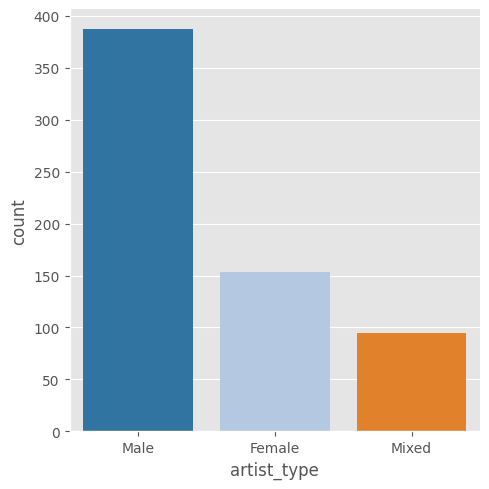

In [5]:
sb.catplot(x='artist_type', data=artists_billboard, kind="count", hue='artist_type', palette="tab20", legend=False)

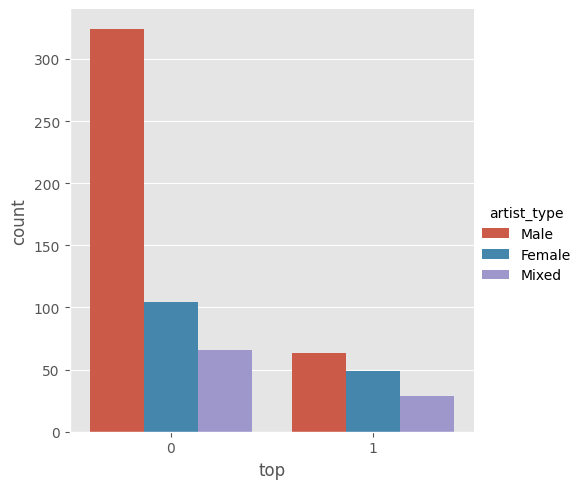

In [6]:
sb.catplot(x='top', data=artists_billboard, kind="count", hue='artist_type')

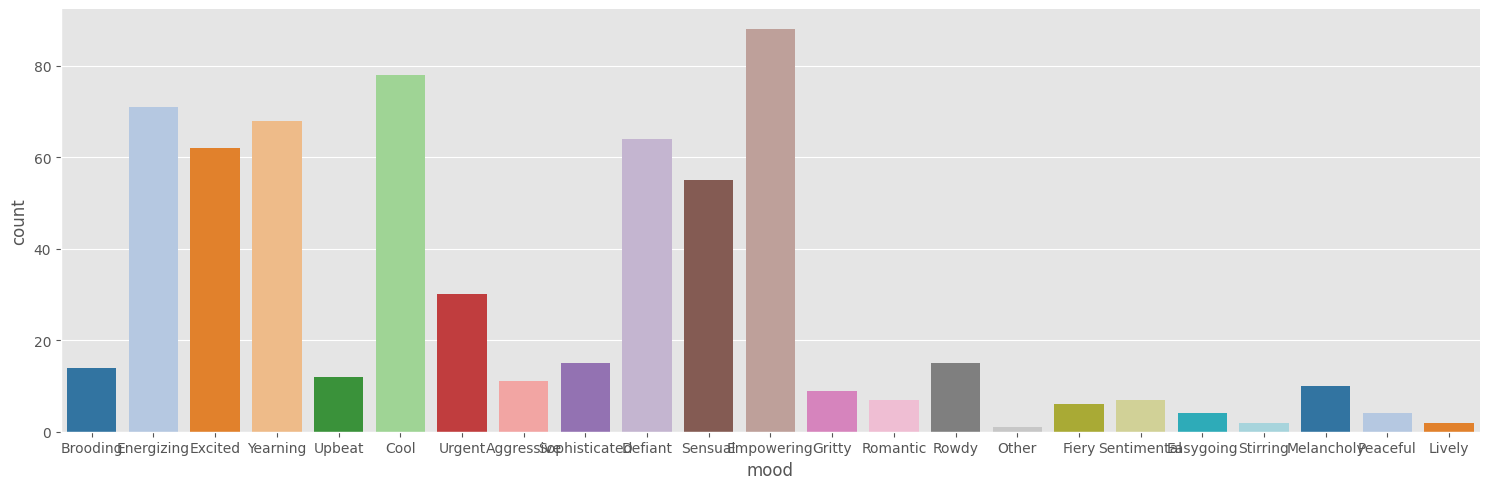

In [7]:
sb.catplot(x='mood', data=artists_billboard, kind="count", aspect=3, hue='mood', palette="tab20", legend=False)

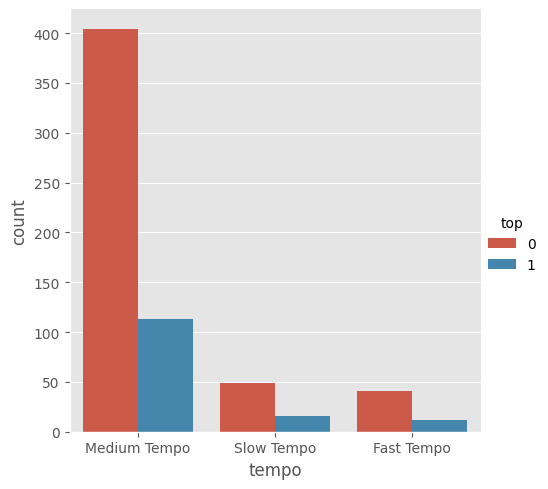

In [8]:
sb.catplot(x='tempo', data=artists_billboard, kind="count", hue='top')

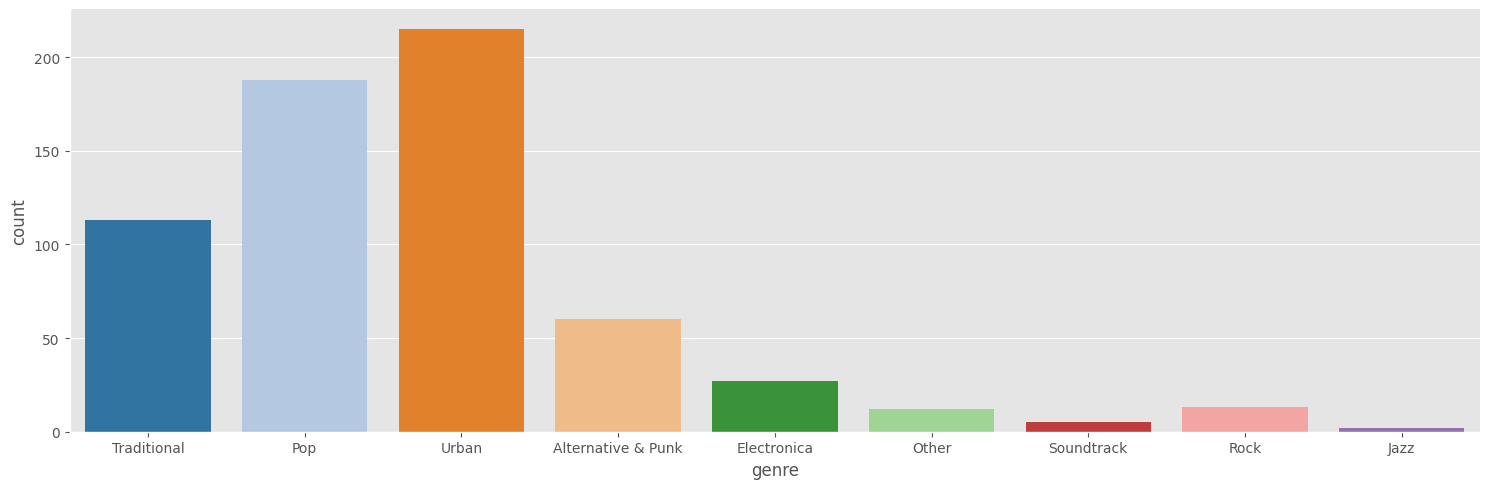

In [9]:
sb.catplot(x='genre', data=artists_billboard, kind="count", aspect=3, hue='genre', palette="tab20", legend=False)

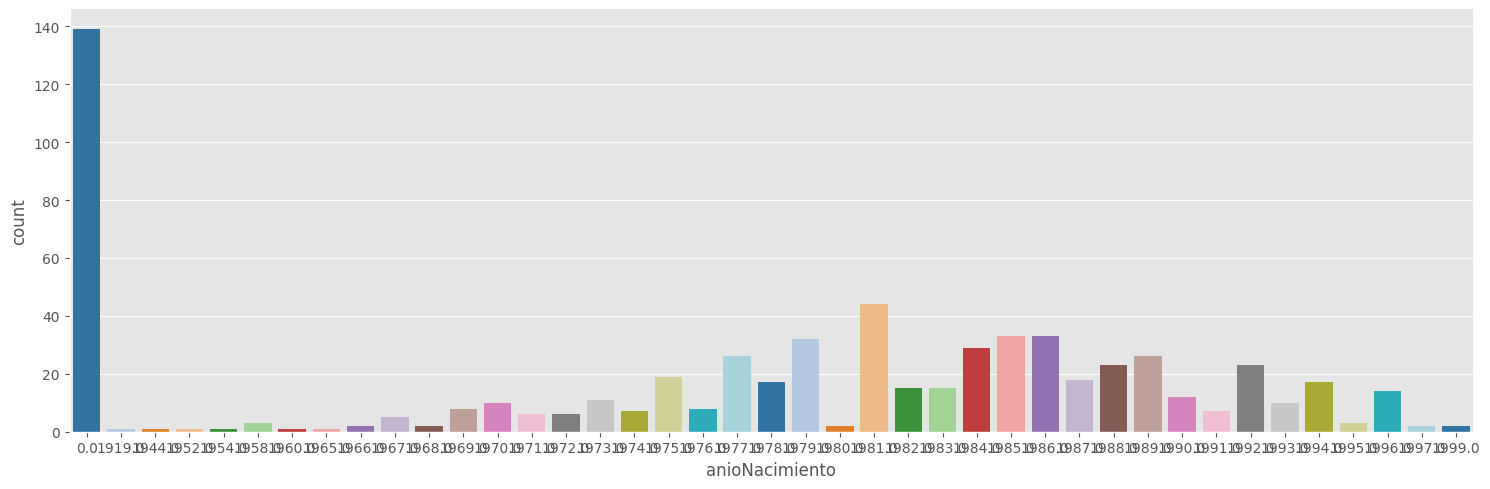

In [10]:
sb.catplot(x='anioNacimiento', data=artists_billboard, kind="count", aspect=3, hue='anioNacimiento', palette="tab20", legend=False)

### Comparación entre los 'top' y los 'no-top'

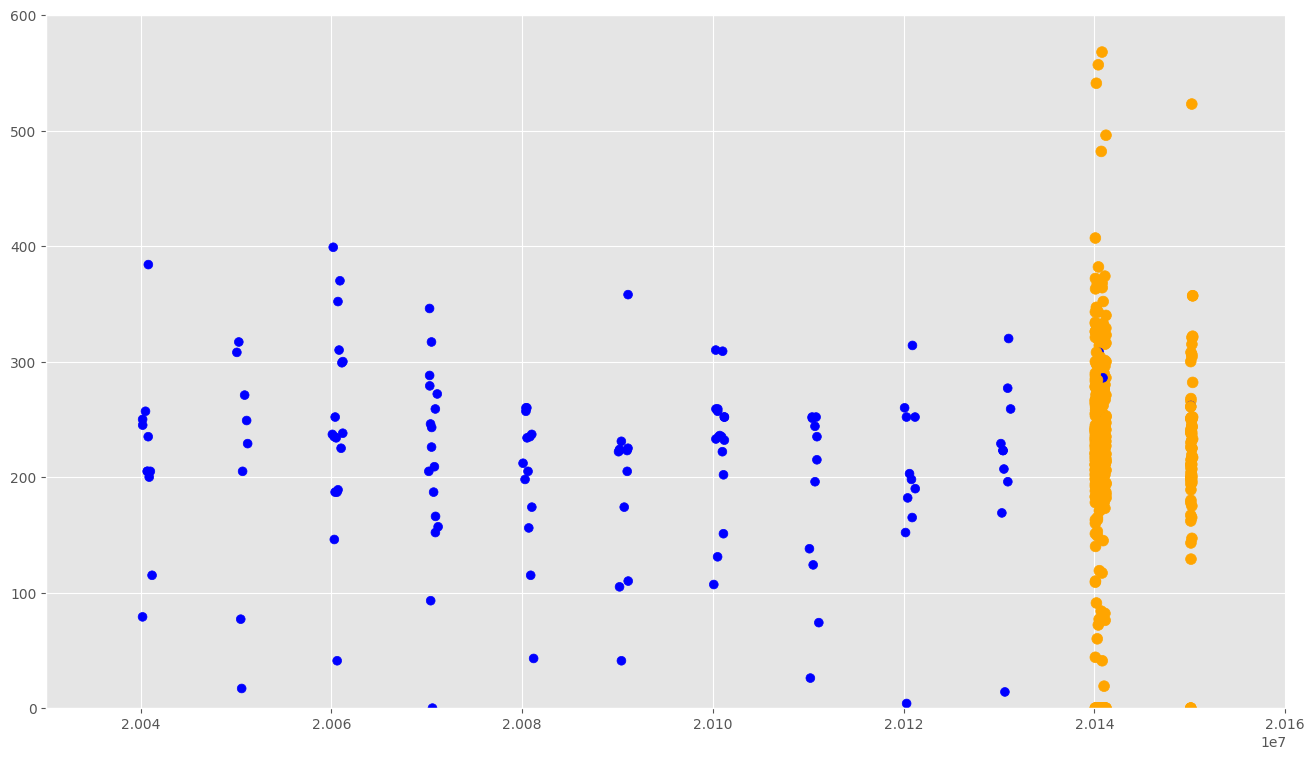

In [11]:
colores = ['orange', 'blue']
tamanios = [60, 40]

f1 = artists_billboard['chart_date'].values
f2 = artists_billboard['durationSeg'].values

asignar = []
asignar2 = []

for index, row in artists_billboard.iterrows():
    asignar.append(colores[row['top']])
    asignar2.append(tamanios[row['top']])

plt.scatter(f1, f2, c=asignar, s=asignar2)
plt.axis([20030101, 20160101, 0, 600])
plt.show()

### Preparación de las edades de los artistas.

In [12]:
def edad_fix(anio):
    if anio == 0:
        return None
    return anio

artists_billboard['anioNacimiento'] = artists_billboard.apply(lambda x: edad_fix(x['anioNacimiento']), axis=1)

In [13]:
def calcula_edad(anio, cuando):
    cad = str(cuando)
    momento = cad[:4]
    if anio == 0:
        return None
    return int(momento) - anio

artists_billboard['edad_en_billboard'] = artists_billboard.apply(lambda x: calcula_edad(x['anioNacimiento'], x['chart_date']), axis=1)

In [14]:
artists_billboard.head()

,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento,edad_en_billboard
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191.0,0,1975.0,39.0
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368.0,0,1989.0,25.0
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223.0,1,1993.0,21.0
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206.0,0,1989.0,25.0
4,4,Automatic,MIRANDA LAMBERT,Yearning,Medium Tempo,Traditional,Female,20140301,232.0,0,NaN,NaN


### Cálculo de la edad promedio y asignación de registros nulos

In [15]:
age_avg = artists_billboard['edad_en_billboard'].mean()
age_std = artists_billboard['edad_en_billboard'].std()
age_null_count = artists_billboard['edad_en_billboard'].isnull().sum()
age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)

conValoresNulos = np.isnan(artists_billboard['edad_en_billboard'])

artists_billboard.loc[np.isnan(artists_billboard['edad_en_billboard']), 'edad_en_billboard'] = age_null_random_list
artists_billboard['edad_en_billboard'] = artists_billboard['edad_en_billboard'].astype(int)
print('Edad promedio: ' + str(age_avg))
print('Desvío Std Edad: ' + str(age_std))
print('Intervalo para asignar edad aleatoria: ' + str(int(age_avg - age_std)) + ' a ' + str(int(age_avg + age_std)))

Edad promedio: 30.10282258064516
Desvío Std Edad: 8.40078832861513
Intervalo para asignar edad aleatoria: 21 a 38


### Visualización de las edades

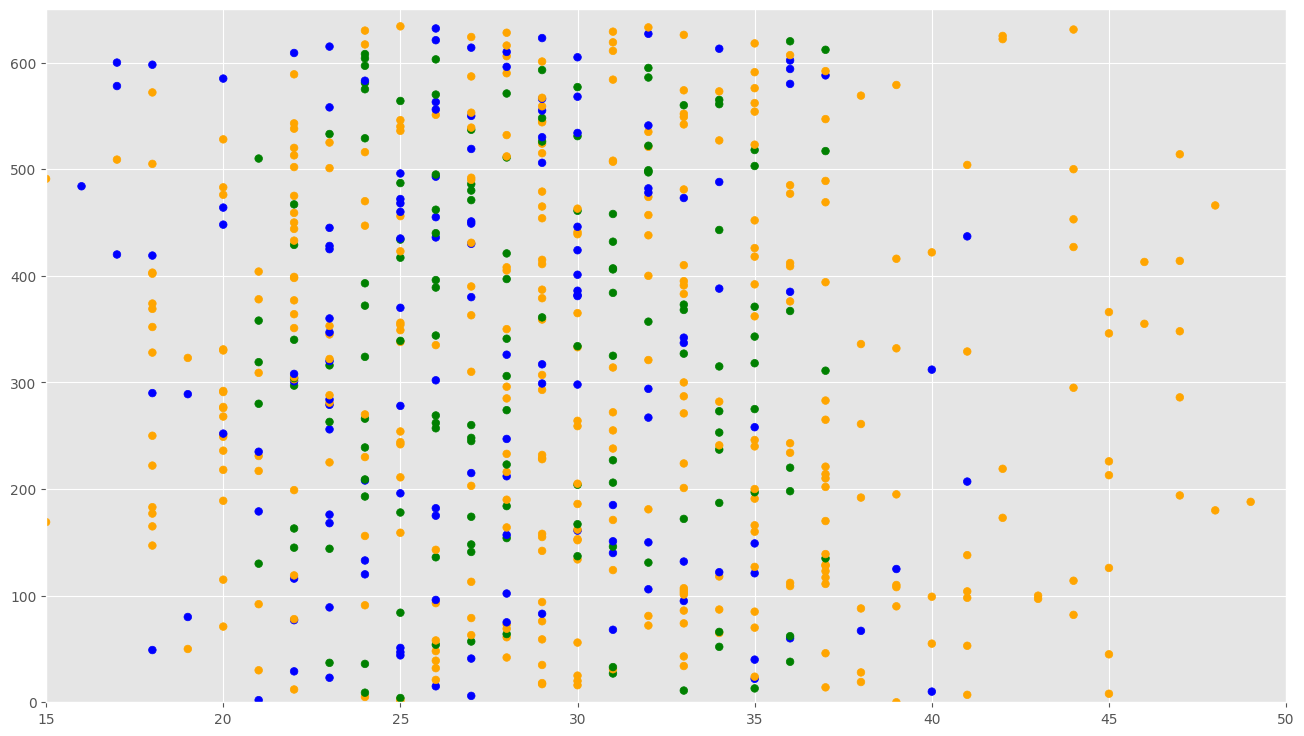

In [16]:
f1 = artists_billboard['edad_en_billboard'].values
f2 = artists_billboard.index

colores = ['orange', 'blue', 'green']

asignar = []
for index, row in artists_billboard.iterrows():
    if (conValoresNulos[index]):
        asignar.append(colores[2]) # Verde
    else:
        asignar.append(colores[row['top']])

plt.scatter(f1, f2, c=asignar, s=30)
plt.axis([15, 50, 0, 650])
plt.show()

### Mapeo de datos

In [17]:
# Mood Mapping 
artists_billboard['moodEncoded'] = artists_billboard['mood'].map( {'Energizing': 6, 
                                        'Empowering': 6,
                                        'Cool': 5, 
                                        'Yearning': 4, # anhelo, deseo, ansia
                                        'Excited': 5, #emocionado
                                        'Defiant': 3, 
                                        'Sensual': 2, 
                                        'Gritty': 3, #coraje 
                                        'Sophisticated': 4,
                                        'Aggressive': 4, # provocativo
                                        'Fiery': 4, #caracter fuerte
                                        'Urgent': 3, 
                                        'Rowdy': 4, #ruidoso alboroto
                                        'Sentimental': 4,
                                        'Easygoing': 1, # sencillo
                                        'Melancholy': 4, 
                                        'Romantic': 2, 
                                        'Peaceful': 1, 
                                        'Brooding': 4, # melancolico
                                        'Upbeat': 5, #optimista alegre
                                        'Stirring': 5, #emocionante
                                        'Lively': 5, #animado
                                        'Other': 0,'':0} ).astype(int)
# Tempo Mapping
artists_billboard['tempoEncoded'] = artists_billboard['tempo'].map({'Fast Tempo': 0, 'Medium Tempo': 2, 
                                                                    'Slow Tempo': 1, '':0}).astype(int)
# Genre Mapping
artists_billboard['genreEncoded'] = artists_billboard['genre'].map({'Traditional': 2, 
                                            'Pop': 3, 
                                            'Urban': 4, 
                                            'Alternative & Punk': 1, 
                                            'Electronica': 1, 
                                            'Soundtrack': 0, 
                                            'Rock': 0, 
                                            'Jazz': 0, 
                                            'Other': 0, '': 0}).astype(int)
# artist_type Mapping
artists_billboard['artist_typeEncoded'] = artists_billboard['artist_type'].map({'Male': 3, 'Female': 2, 
                                                                                'Mixed': 1})
# Mapping en la que llegaron al billboard
artists_billboard.loc[artists_billboard['artist_typeEncoded'] <= 21, 'edadEncoded'] = 0
artists_billboard.loc[(artists_billboard['artist_typeEncoded'] > 21) & 
                      (artists_billboard['artist_typeEncoded'] <= 26), 'edadEncoded'] = 1
artists_billboard.loc[(artists_billboard['artist_typeEncoded'] > 26) & 
                      (artists_billboard['artist_typeEncoded'] <= 30), 'edadEncoded'] = 2
artists_billboard.loc[(artists_billboard['artist_typeEncoded'] > 30) & 
                      (artists_billboard['artist_typeEncoded'] <= 40), 'edadEncoded'] = 3
artists_billboard.loc[artists_billboard['artist_typeEncoded'] > 40, 'edadEncoded'] = 4

# Mapping Song Duration
artists_billboard.loc[artists_billboard['durationSeg'] <= 150, 'durationEncoded'] = 0
artists_billboard.loc[(artists_billboard['durationSeg'] > 150) & 
                      (artists_billboard['durationSeg'] <= 180), 'durationEncoded'] = 1
artists_billboard.loc[(artists_billboard['durationSeg'] > 180) & 
                      (artists_billboard['durationSeg'] <= 210), 'durationEncoded'] = 2
artists_billboard.loc[(artists_billboard['durationSeg'] > 210) & 
                      (artists_billboard['durationSeg'] <= 240), 'durationEncoded'] = 3
artists_billboard.loc[(artists_billboard['durationSeg'] > 240) & 
                      (artists_billboard['durationSeg'] <= 270), 'durationEncoded'] = 4
artists_billboard.loc[(artists_billboard['durationSeg'] > 270) & 
                      (artists_billboard['durationSeg'] <= 300), 'durationEncoded'] = 5
artists_billboard.loc[artists_billboard['durationSeg'] > 300, 'durationEncoded'] = 6

In [18]:
drop_elements = ['id', 'title', 'artist', 'mood', 'tempo', 'genre', 'artist_type', 'chart_date', 
                 'anioNacimiento', 'durationSeg', 'edad_en_billboard',]
artists_encoded = artists_billboard.drop(drop_elements, axis=1)

### Posicionamiento de los top con relación a los datos mapeados

In [19]:
artists_encoded.head()

,top,moodEncoded,tempoEncoded,genreEncoded,artist_typeEncoded,edadEncoded,durationEncoded
0,0,4,2,2,3,0.0,2.0
1,0,6,2,3,2,0.0,6.0
2,1,5,2,4,1,0.0,3.0
3,0,4,2,1,3,0.0,2.0
4,0,4,2,2,2,0.0,3.0


In [20]:
artists_encoded[['moodEncoded', 'top']].groupby(['moodEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

moodEncoded       top          
                   mean count sum
0           0  0.000000     1   0
1           1  0.000000     8   0
2           2  0.274194    62  17
3           3  0.145631   103  15
4           4  0.136986   146  20
5           5  0.294872   156  46
6           6  0.270440   159  43

In [21]:
artists_encoded[['artist_typeEncoded', 'top']].groupby(['artist_typeEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

artist_typeEncoded       top          
                          mean count sum
0                  1  0.305263    95  29
1                  2  0.320261   153  49
2                  3  0.162791   387  63

In [22]:
artists_encoded[['genreEncoded', 'top']].groupby(['genreEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

genreEncoded       top          
                    mean count sum
0            0  0.062500    32   2
1            1  0.080460    87   7
2            2  0.008850   113   1
3            3  0.319149   188  60
4            4  0.330233   215  71

In [23]:
artists_encoded[['tempoEncoded', 'top']].groupby(['tempoEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

tempoEncoded       top           
                    mean count  sum
0            0  0.226415    53   12
1            1  0.246154    65   16
2            2  0.218569   517  113

In [24]:
artists_encoded[['durationEncoded', 'top']].groupby(['durationEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

durationEncoded       top          
                       mean count sum
0             0.0  0.295775    71  21
1             1.0  0.333333    30  10
2             2.0  0.212963   108  23
3             3.0  0.202381   168  34
4             4.0  0.232143   112  26
5             5.0  0.145455    55   8
6             6.0  0.208791    91  19

In [25]:
artists_encoded[['edadEncoded', 'top']].groupby(['edadEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

edadEncoded       top           
                   mean count  sum
0         0.0  0.222047   635  141

### Búsqueda de profundidad para el árbol de decisión

In [32]:
cv = KFold(n_splits=10)
accuracies = list()
max_attributes = len(list(artists_encoded))
depth_range = range(1, max_attributes + 1)

for depth in depth_range:
    fold_accuracy = []
    tree_model = tree.DecisionTreeClassifier(criterion='entropy', 
                                             min_samples_split=20, 
                                             min_samples_leaf=5, 
                                             max_depth=depth, 
                                             class_weight={1: 3.5})
    for train_fold, valid_fold in cv.split(artists_encoded):
        f_train = artists_encoded.loc[train_fold]
        f_valid = artists_encoded.loc[valid_fold]
        model = tree_model.fit(X = f_train.drop(['top'], axis=1), y = f_train['top'])
        valid_acc = model.score(X = f_valid.drop(['top'], axis=1), y = f_valid['top'])
        fold_accuracy.append(valid_acc)
    avg = sum(fold_accuracy) / len(fold_accuracy)
    accuracies.append(avg)

# Muestra de resultados obtenidos.
df = pd.DataFrame({"Max Depth": depth_range, "Average Accuracy": accuracies})
df = df[["Max Depth", "Average Accuracy"]]
print(df.to_string(index=False))

 Max Depth  Average Accuracy
         1          0.556101
         2          0.556101
         3          0.623710
         4          0.617460
         5          0.618973
         6          0.606250
         7          0.617312


### Visualización del árbol de decisión

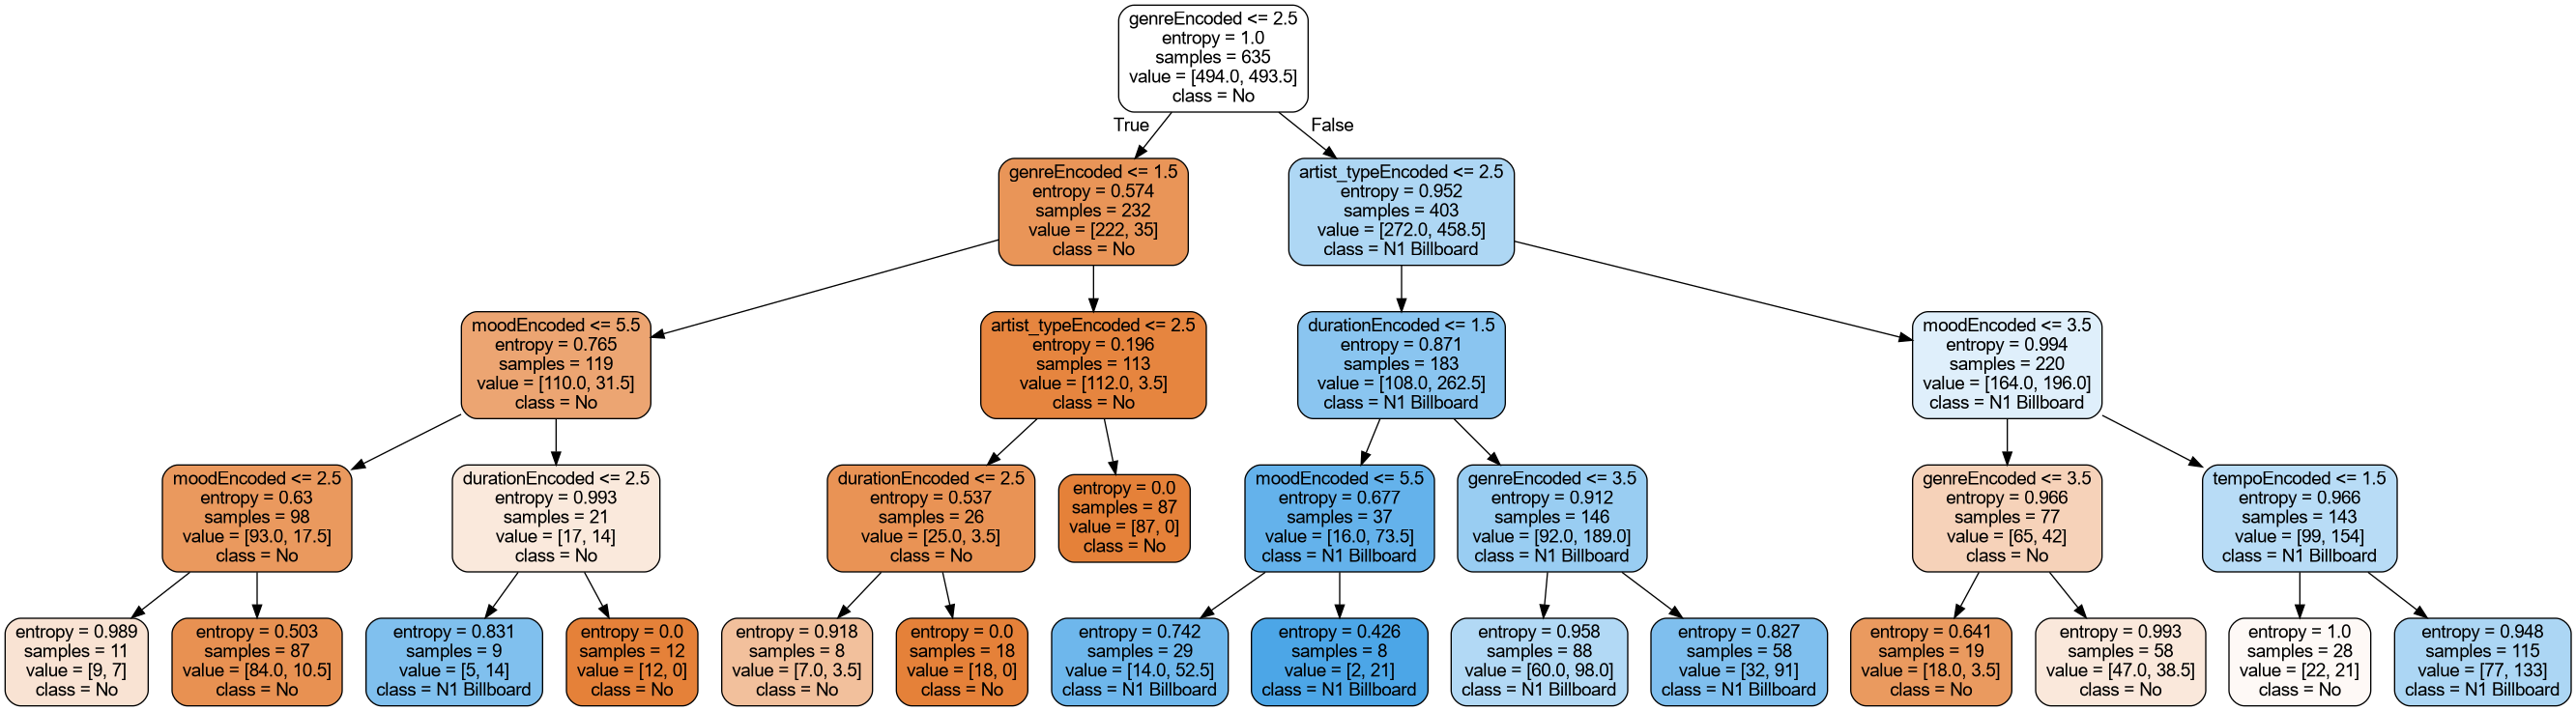

In [34]:
# Crear arrays de entrenamiento y las etiquetas que indican si llegó a top o no.
y_train = artists_encoded['top']
x_train = artists_encoded.drop(['top'], axis=1).values

# Crear árbol de decisión con profundidad = 4.
decision_tree = tree.DecisionTreeClassifier(criterion='entropy',
                                            min_samples_split=20,
                                            min_samples_leaf=5,
                                            max_depth=4,
                                            class_weight={1: 3.5})
decision_tree.fit(x_train, y_train)

# Exportar el árbol de decisión a un archivo .dot
with open(r"tree1.dot", 'w') as f:
    f = tree.export_graphviz(decision_tree, 
                             out_file=f, 
                             max_depth=7, 
                             impurity=True,
                             feature_names=list(artists_encoded.drop(['top'], axis=1)), 
                             class_names=['No', 'N1 Billboard'],
                             rounded=True,
                             filled=True)

# Convertir el archivo .dot a formato PNG
check_call(['dot', '-Tpng', r'tree1.dot', '-o', r'tree1.png'])
PImage("tree1.png")

### Análisis del árbol

In [35]:
acc_decision_tree = round(decision_tree.score(x_train, y_train) * 100, 2)
print(acc_decision_tree)

66.3


### Predicción del árbol de decisión

In [50]:
# predecir artista CAMILA CABELLO featuring YOUNG THUG
# con su canción Havana llego a numero 1 Billboard US en 2017

x_test = pd.DataFrame(columns=('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded', 
                               'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))
x_test.loc[0] = (1, 5, 2, 4, 1, 0, 3)
y_pred = decision_tree.predict(x_test.drop(['top'], axis = 1).values)
print("Predicción: " + str(y_pred))
y_proba = decision_tree.predict_proba(x_test.drop(['top'], axis = 1).values)
print("Probabilidad de acierto: " + str(round(y_proba[0][y_pred[0]] * 100, 2)) + "%")

Predicción: [1]
Probabilidad de acierto: 73.98%


In [51]:
# predecir artista Imagine Dragons 
# con su canción Believer llego al puesto 42 Billboard US en 2017

x_test = pd.DataFrame(columns=('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded', 
                               'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))
x_test.loc[0] = (0, 4, 2, 1, 3, 2, 3)
y_pred = decision_tree.predict(x_test.drop(['top'], axis = 1).values)
print("Predicción: " + str(y_pred))
y_proba = decision_tree.predict_proba(x_test.drop(['top'], axis = 1).values)
print("Probabilidad de acierto: " + str(round(y_proba[0][y_pred[0]] * 100, 2)) + "%")

Predicción: [0]
Probabilidad de acierto: 88.89%
